# Power Consumption Forecasting

In [1]:
# Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Data Collection
df = pd.read_csv("../data/Power_Consumption_Data.csv")
quarter_map = {"Q1": "-01-01", "Q2": "-04-01", "Q3": "-07-01", "Q4": "-10-01"}
df["Quarter"] = (
    df["Quarter"]
    .str.replace(" Q1", quarter_map["Q1"])
    .str.replace(" Q2", quarter_map["Q2"])
    .str.replace(" Q3", quarter_map["Q3"])
    .str.replace(" Q4", quarter_map["Q4"])
)

df["Quarter"] = pd.to_datetime(df["Quarter"])
df.set_index("Quarter", inplace=True)
df["Consumption"] = df["Consumption"].astype(int)

display(df.head(5))
display(df.info())
display(df.describe())

,Consumption
Quarter,
2001-01-01,22164839
2001-04-01,22952510
2001-07-01,25962808
2001-10-01,21357650
2002-01-01,21917084


<class 'pandas.DataFrame'>
DatetimeIndex: 80 entries, 2001-01-01 to 2020-10-01
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Consumption  80 non-null     int64
dtypes: int64(1)
memory usage: 1.2 KB


None

,Consumption
count,8.000000e+01
mean,2.330880e+07
std,4.137809e+06
min,1.102928e+07
25%,2.186000e+07
50%,2.413629e+07
75%,2.534612e+07
max,3.187314e+07


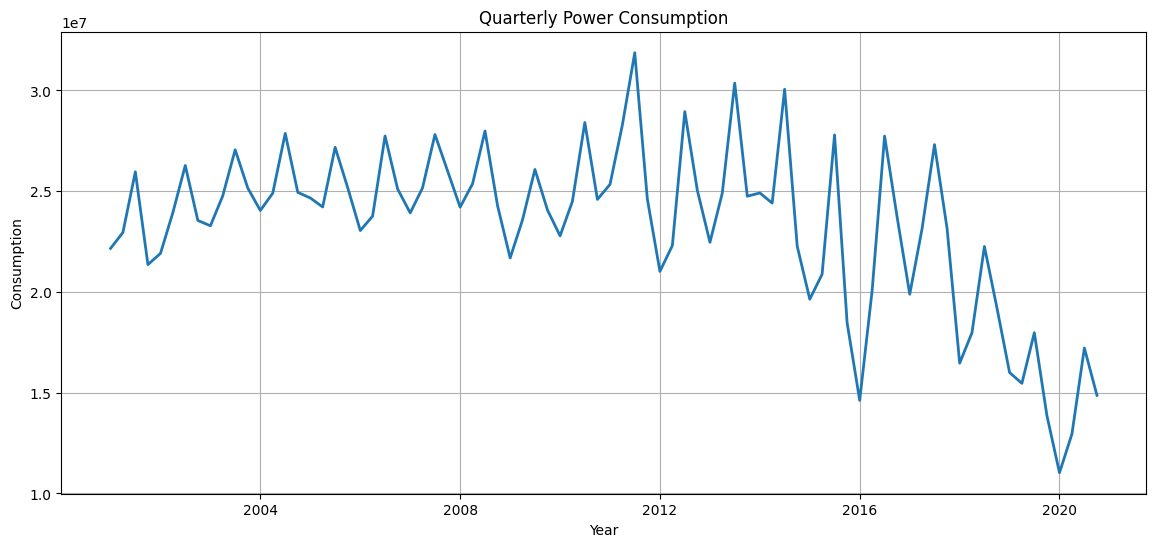

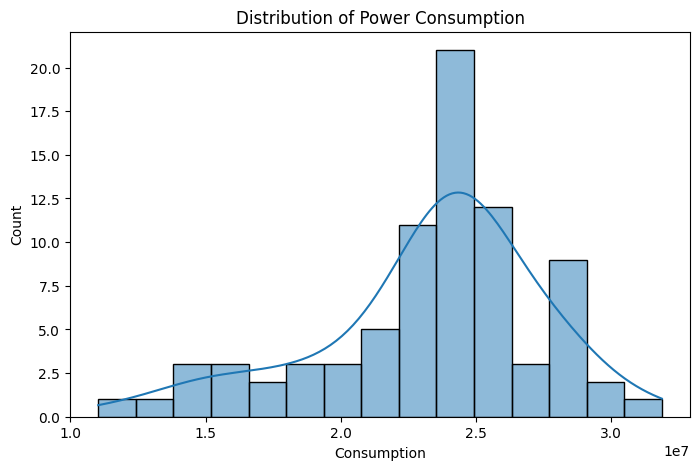

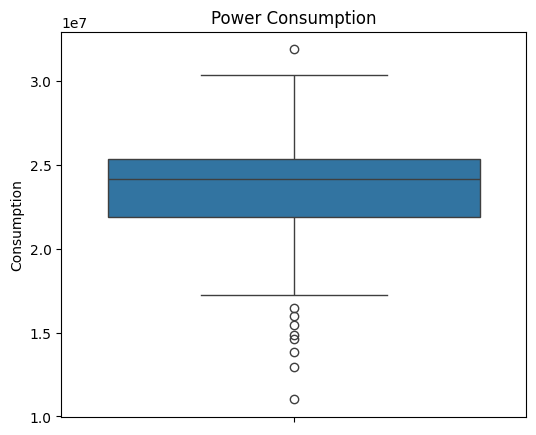

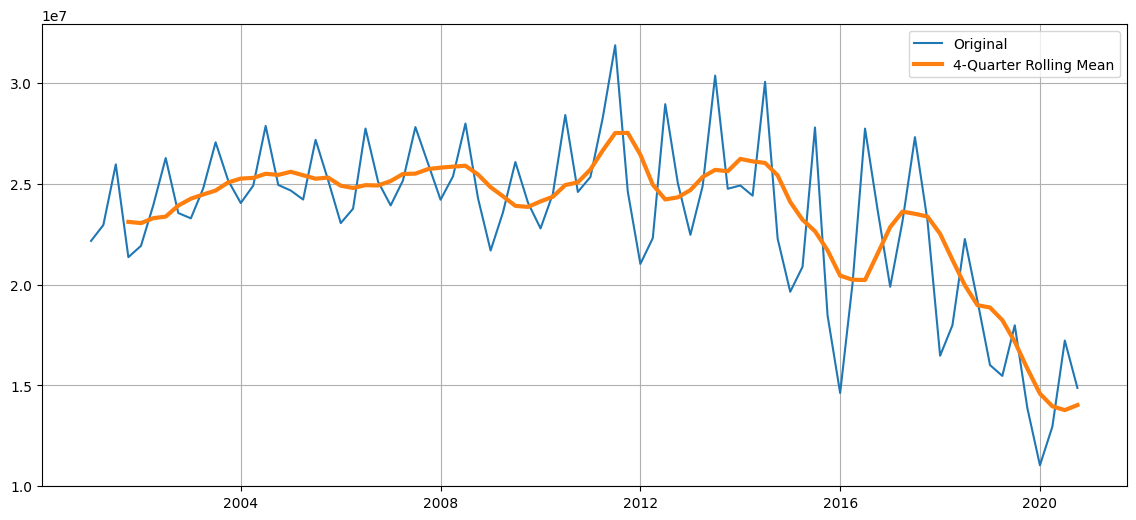

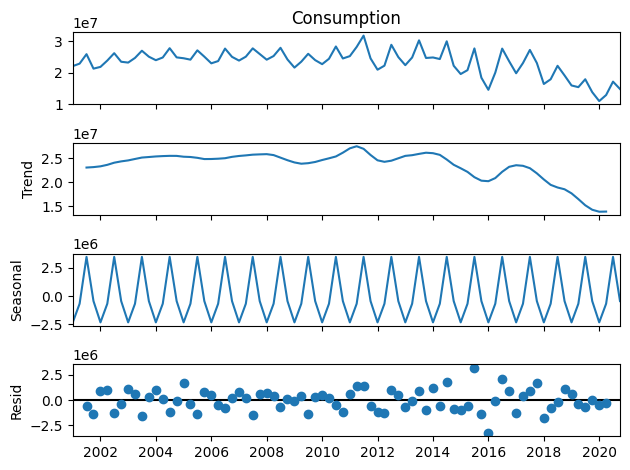

In [2]:
# Data Visualization
plt.figure(figsize=(14,6))
plt.plot(df.index, df["Consumption"], linewidth=2)
plt.title("Quarterly Power Consumption")
plt.xlabel("Year")
plt.ylabel("Consumption")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(df["Consumption"], bins=15, kde=True)
plt.title("Distribution of Power Consumption")
plt.show()

plt.figure(figsize=(6,5))
sns.boxplot(y=df["Consumption"])
plt.title("Power Consumption")
plt.show()

plt.figure(figsize=(14,6))
plt.plot(df.index, df["Consumption"], label="Original")
plt.plot(df["Consumption"].rolling(window=4).mean(), label="4-Quarter Rolling Mean", linewidth=3)
plt.legend()
plt.grid(True)
plt.show()

decomposition = seasonal_decompose(df["Consumption"], model="additive", period=4)
decomposition.plot()
plt.show()

In [3]:
result = adfuller(df["Consumption"])
print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] < 0.05:
    print("Series is stationary")
else:
    print("Series is not stationary")


# Train Test Split
train = df.iloc[:-8]
test = df.iloc[-8:]
print(train.shape)
print(test.shape)


model = ExponentialSmoothing(
    train["Consumption"],
    trend="add",
    seasonal="add",
    seasonal_periods=4
)

fit = model.fit()
predictions = fit.forecast(len(test))

ADF Statistic: 1.9763029096941296
p-value: 0.9986413567364828
Series is not stationary
(72, 1)
(8, 1)


C:\Users\hp\newenv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)


In [4]:
# Model Evaluation
mae = mean_absolute_error(test["Consumption"], predictions)
rmse = np.sqrt(mean_squared_error(test["Consumption"], predictions))
mape = mean_absolute_percentage_error(test["Consumption"], predictions)

print(f"MAE  : {mae:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"MAPE : {mape*100:.2f}%")

MAE  : 3,659,977.93
RMSE : 3,896,225.86
MAPE : 24.51%


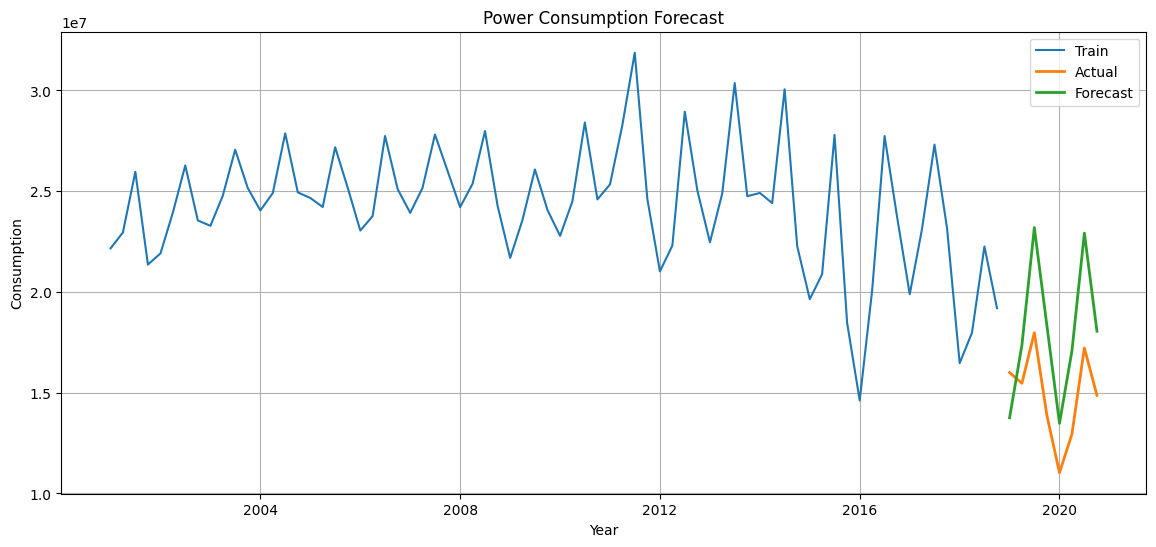

2019-01-01    1.375467e+07
2019-04-01    1.735345e+07
2019-07-01    2.319607e+07
2019-10-01    1.832620e+07
2020-01-01    1.348054e+07
2020-04-01    1.707932e+07
2020-07-01    2.292194e+07
2020-10-01    1.805207e+07
Freq: QS-OCT, dtype: float64


In [5]:
# Plot Actual vs Predicted
plt.figure(figsize=(14,6))

plt.plot(train.index, train["Consumption"], label="Train")
plt.plot(test.index, test["Consumption"], label="Actual", linewidth=2)
plt.plot(test.index, predictions, label="Forecast", linewidth=2)
plt.title("Power Consumption Forecast")
plt.xlabel("Year")
plt.ylabel("Consumption")
plt.legend()
plt.grid(True)
plt.show()


# Forecast Future 8 Quarters
future = fit.forecast(8)
print(future)